In [ ]:
import argparse
import glob
import numpy as np
import pandas as pd


def get_args():
    parser = argparse.ArgumentParser(
        description="Process a NEXT100 run and build summaries")
    parser.add_argument(
        "-r", "-run", "--run",
        dest="run_number",
        type=int,
        required=True,
        help="Run number to analyse, e.g. 15107")
    parser.add_argument(
        "-i", "--in_name",
        dest="input_name",
        type=str,
        default="run_summary.h5",
        help="Name of the input files")
    parser.add_argument(
        "-s", "--save",
        dest="save_name",
        type=str,
        default="run_summary.h5",
        help="Name of the file to save")
    parser.add_argument(
        "-l", "--ldc",
        dest="ldc_name",
        type=str,
        default="*",
        help="Name of the ldc to run over")
    return parser.parse_args()

args        = get_args()
run_number  = args.run_number
input_name  = args.in_name
ldc_name    = args.ldc_name
save_name   = args.save_name

summary_path  = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/new_HE_runs/' 
summary_file = summary_path + '/{run_n}/'.format(run_n = run_number) + ldc_name + input_name

save_path = summary_path + '/{run_n}/'.format(run_n = run_number) + save_name

def lineal(x, a, b):
    return a * x + b

def in_range(x, min_, max_):
    return (x > min_) & (x < max_)

def apply_dst_cuts(dst, s1_DT_cut = [0.32, 500]):
    # Had to decouple cuts 
    #1S1
    dst_S1 = dst[dst.nS1 == 1]
    nev_S1 = len(dst_S1.event.unique())
    #1S2
    dst_S2 = dst_S1[dst_S1.nS2 == 1]
    nev_S2 = len(dst_S2.event.unique())
    #DT > 0
    dst_DT = dst_S2[dst_S2.DT > 0].copy()
    nev_DT = len(dst_DT.event.unique())
    #alphas
    dst_DT['limS1e'] = lineal(dst_DT.DT, s1_DT_cut[0], s1_DT_cut[1])
    dst_al = dst_DT[dst_DT.S1e < dst_DT.limS1e]
    nev_al = len(dst_al.event.unique())
    return dst_DT, [nev_S1, nev_S2, nev_DT, nev_al]

def apply_fid_cuts(reco):
    # R
    reco_r = reco[in_range(reco.Rmax , 0, 450)]
    nev_r = len(reco_r.event.unique())
    # Z
    reco_fid = reco_r[in_range(reco_r.Zmin , 20, 1369*0.865) & in_range(reco_r.Zmax , 20, 1369*0.865)]
    nev_f = len(reco_fid.event.unique())
    return reco_fid, [nev_r, nev_f]

files = sorted(glob.glob(summary_file), key=lambda x: x.split('/')[-1].split('_')[0])

eff = np.array([0] * 7) # to compute efficiencies

for i, f in enumerate(files):
    nev = []
    try:
        dst = pd.read_hdf(f, 'DST/Events')
        reco = pd.read_hdf(f, 'RECO/Events_summary')
    except Exception as e:
        print(f"Skipping corrupted/invalid file: {f}")
        print(f"Error: {e}")
        continue

    if reco.empty:
        print(f"Skipping empty file: {f}")
        continue

    nev_initial = len(dst.event.unique())
    nev.extend([nev_initial])
    dst, nev_dst = apply_dst_cuts(dst)
    nev.extend(nev_dst)
    reco = reco[np.isin(reco.event, dst.event.unique())]
    # check no dst is empty after cuts
    if dst.empty:
        print(f"DST empty after initial cuts: {f}")
        continue
    reco, nev_reco = apply_fid_cuts(reco)
    nev.extend(nev_reco)
    dst = dst[np.isin(dst.event, reco.event.unique())]

    eff += np.array(nev)


    dst.to_hdf (save_path, key = 'DST/Events', mode = 'a', append= True, complib="zlib", complevel=4)
    reco.to_hdf(save_path, key = 'RECO/Events_summary', mode = 'a', append= True, complib="zlib", complevel=4)
    
    print(i)
    
eff_df = pd.DataFrame([eff],columns = ['total', '1S1', '1S2', 'DT', 'alphas', 'rad', 'z'])
eff_df.to_hdf(save_path, 'RUN/eff', complib="zlib", complevel=4)


In [44]:
run_summ = pd.read_hdf(save_path, 'RECO/Events_summary')

In [45]:
eff = pd.read_hdf(save_path, 'RUN/eff')

In [6]:
import matplotlib.pyplot as plt

In [48]:
sp_range = (0.47, 0.67)
dep_range = (1.55, 1.8)
pp_range = (2.6, 2.9)

Text(0.5, 1.0, 'Run 15589')

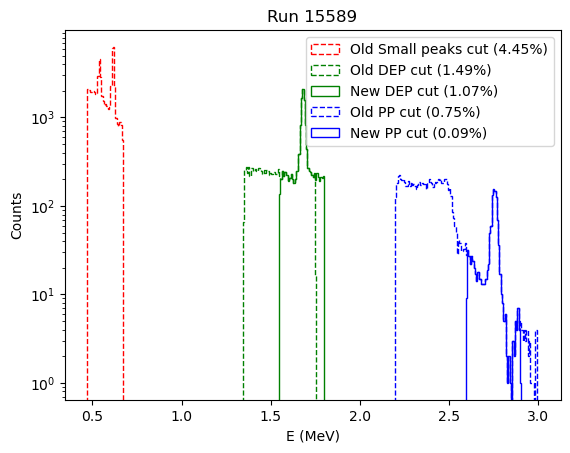

In [50]:

sp_events = run_summ[in_range(run_summ.total_energy, 0.47, 0.67)]
plt.hist(sp_events.total_energy, 350, (0.47, 3), color = 'r', ls = '--', histtype='step', label = 'Old Small peaks cut ({:.2f}%)'.format((len(sp_events) * 100)   / eff.total.values[0]))

dep_old_evs = run_summ[in_range(run_summ.total_energy, 1.35, 1.75)]
plt.hist(dep_old_evs.total_energy, 350, (0.47, 3), color = 'g', ls = '--', histtype='step', label = 'Old DEP cut ({:.2f}%)'.format((len(dep_old_evs) * 100)   / eff.total.values[0]))

dep_new_evs = run_summ[in_range(run_summ.total_energy, dep_range[0], dep_range[1])]
plt.hist(dep_new_evs.total_energy, 350, (0.47, 3), color = 'g', histtype='step', label = 'New DEP cut ({:.2f}%)'.format((len(dep_new_evs) * 100)   / eff.total.values[0]))

pp_old_evs = run_summ[in_range(run_summ.total_energy, 2.2, 3)]
plt.hist(pp_old_evs.total_energy, 350, (0.47, 3), color = 'b', ls = '--',histtype='step', label = 'Old PP cut ({:.2f}%)'.format((len(pp_old_evs) * 100)   / eff.total.values[0]))

pp_new_evs = run_summ[in_range(run_summ.total_energy, pp_range[0], pp_range[1])]
plt.hist(pp_new_evs.total_energy, 350, (0.47, 3), color = 'b', histtype='step', label = 'New PP cut ({:.2f}%)'.format((len(pp_new_evs) * 100)   / eff.total.values[0]))

# plt.hist(selwf3d.total_energy, 300, histtype='step', label = '3D cluster drop')
plt.legend()
plt.yscale('log')
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.title(f"Run {run_number}")

In [1]:
import argparse
import glob
import numpy as np
import pandas as pd

In [ ]:
import glob
import pandas as pd

In [3]:
run_number = 15591
summary_path  = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/new_HE_runs/' 
for f in glob.glob(summary_path + '/{}/ldc*sel_wf_*'.format(run_number)):
    sel = pd.read_hdf(f, 'RUN/Selected_events')
    sel.to_hdf(summary_path + '/{}/'.format(run_number) + 'sel_wf_{}'.format(run_number) + '.h5', key = 'RUN/Selected_events', mode = 'a', append = True, complib="zlib", complevel=4)

In [ ]:
import argparse
import glob
import pandas as pd

def get_args():
    parser = argparse.ArgumentParser(
        description="Process a NEXT100 run and build summaries")
    parser.add_argument(
        "-r", "-run", "--run",
        dest="run_number",
        type=int,
        required=True,
        help="Run number to analyse, e.g. 15107")
    parser.add_argument(
        "-i", "--in_name",
        dest="input_name",
        type=str,
        default="run_summary.h5",
        help="Name of the input files")
    parser.add_argument(
        "-s", "--save",
        dest="save_name",
        type=str,
        default="run_summary.h5",
        help="Name of the file to save")
    parser.add_argument(
        "-l", "--ldc",
        dest="ldc_name",
        type=str,
        default="*",
        help="Name of the ldc to run over")
    return parser.parse_args()

args        = get_args()
run_number  = args.run_number
input_name  = args.input_name
ldc_name    = args.ldc_name
save_name   = args.save_name

summary_path  = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/new_HE_runs/' 

for f in glob.glob(summary_path + '/{}/'.format(run_number) + ldc_name + input_name):
    sel = pd.read_hdf(f, 'RUN/Selected_events')
    sel.to_hdf(summary_path + '/{}/'.format(run_number) + save_name, key = 'RUN/Selected_events', mode = 'a', append = True, complib="zlib", complevel=4)

In [4]:
cosa = pd.read_hdf(summary_path + '/{}/'.format(run_number) + 'sel_wf_{}'.format(run_number) + '.h5', key = 'RUN/Selected_events')

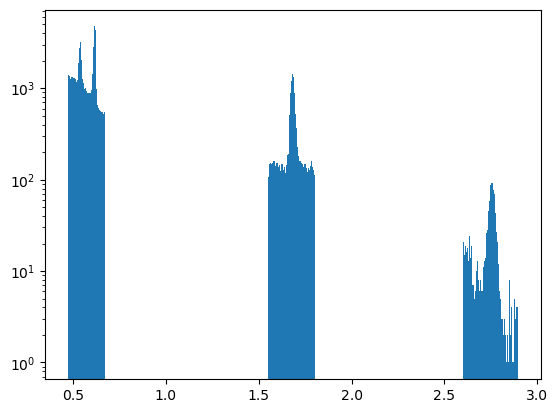

In [7]:
plt.hist(cosa.total_energy, 500)
plt.yscale('log')